# 02 — Feature Engineering

The raw dataset contains basic customer attributes. This notebook creates a few engineered features that may help models capture churn behaviour more effectively.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data_loader import load_or_generate
from src.feature_engineering import (
    engagement_score,
    ticket_rate,
    spend_vs_plan,
    loyalty_score,
    risk_flag,
    add_engineered_features,
)

sns.set_theme(style="whitegrid")
TARGET = "churned"


## 1. Load Dataset

In [2]:
df_raw = load_or_generate()

print(df_raw.shape)

df_raw.head(3)



Missing values detected.
Missing values handled.
(50000, 12)


,customer_id,tenure_months,monthly_spend,num_support_tickets,last_login_days_ago,feature_adoption_score,plan_type,contract_type,region,has_referral,num_integrations,churned
0,C00000,52,213.12,1,35,0.268,Free,Annual,EMEA,0,12,0
1,C00001,15,141.39,2,17,0.100,Free,Month-to-Month,LATAM,1,4,1
2,C00002,61,73.17,4,79,0.051,Starter,Two-Year,LATAM,0,7,0


The dataset contains both numerical and categorical customer features. The target column is `churned`, where 1 represents customers who left the platform.

## 2. Generate Engineered Features

`plan_medians` are used for the `spend_vs_plan` feature.

In [3]:
plan_medians = (
    df_raw.groupby("plan_type")["monthly_spend"]
    .median()
    .to_dict()
)

print("Plan medians:")

for k, v in sorted(plan_medians.items()):
    print(f"{k}: {v:.2f}")


Plan medians:
Enterprise: 81.64
Free: 82.58
Pro: 82.32
Starter: 85.06


In [4]:
df = add_engineered_features(
    df_raw,
    plan_medians,
)

engineered = [
    "engagement_score",
    "ticket_rate",
    "spend_vs_plan",
    "loyalty_score",
    "risk_flag",
]

print("Added columns:", engineered)

df[engineered].describe().T.round(2)


Added columns: ['engagement_score', 'ticket_rate', 'spend_vs_plan', 'loyalty_score', 'risk_flag']


,count,mean,std,min,25%,50%,75%,max
engagement_score,50000.0,0.54,0.14,0.03,0.45,0.55,0.64,0.96
ticket_rate,50000.0,0.07,0.12,0.00,0.01,0.04,0.08,1.50
spend_vs_plan,50000.0,1.45,1.44,0.00,0.42,1.00,2.01,13.57
loyalty_score,50000.0,5.88,3.09,0.69,3.64,4.72,8.01,15.40
risk_flag,50000.0,0.16,0.44,0.00,0.00,0.00,0.00,2.00


The engineered features introduce additional behavioural information that is not directly available from the raw dataset.

## 3. Preview New Features

In [5]:
df[
    ["customer_id", TARGET] + engineered
].head(8)


,customer_id,churned,engagement_score,ticket_rate,spend_vs_plan,loyalty_score,risk_flag
0,C00000,0,0.638865,0.018692,2.580770,7.940584,0
1,C00001,1,0.494134,0.117783,1.712158,3.327106,0
2,C00002,0,0.261061,0.062520,0.860216,12.381403,1
3,C00003,0,0.500099,0.044452,2.504723,3.091042,0
4,C00004,0,0.296676,0.039221,1.919109,9.656627,0
5,C00005,1,0.439590,0.000000,2.008582,1.386294,0
6,C00006,0,0.501980,0.083382,0.483306,3.135494,0
7,C00007,0,0.262208,0.018349,1.408285,7.977968,0


## 4. Feature-by-Feature Explanation

### 4.1 `engagement_score`

This feature combines:
- feature adoption
- login activity
- integrations

Higher engagement generally relates to lower churn.


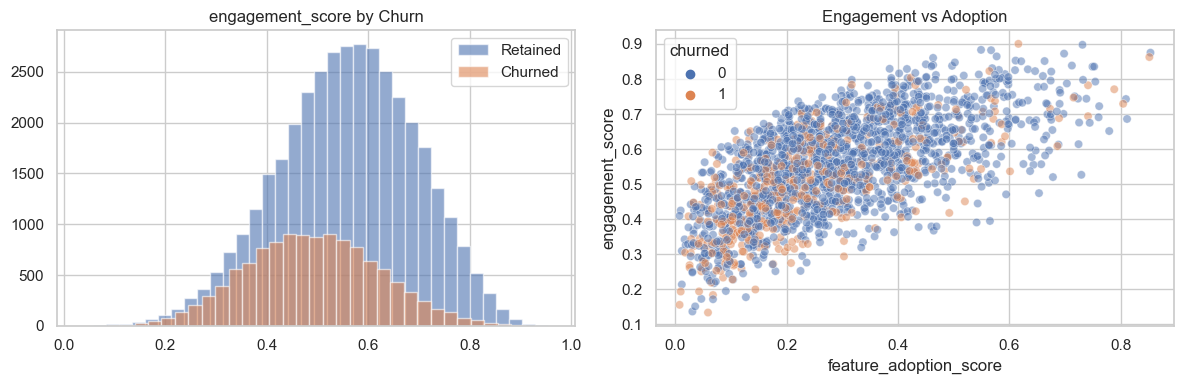

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, lbl in [
    (0, "Retained"),
    (1, "Churned"),
]:

    axes[0].hist(
        df.loc[df[TARGET] == label, "engagement_score"],
        bins=35,
        alpha=0.6,
        label=lbl,
    )

axes[0].set_title(
    "engagement_score by Churn"
)

axes[0].legend()

sample = df.sample(
    2000,
    random_state=42,
)

sns.scatterplot(
    data=sample,
    x="feature_adoption_score",
    y="engagement_score",
    hue=TARGET,
    alpha=0.5,
    ax=axes[1],
)

axes[1].set_title(
    "Engagement vs Adoption"
)

plt.tight_layout()
plt.show()


`engagement_score` combines product usage and activity signals into a single metric. Lower values are more common among churned customers.

### 4.2 `ticket_rate`

This feature measures support tickets relative to customer tenure.

Customers with frequent support issues may be more likely to churn.


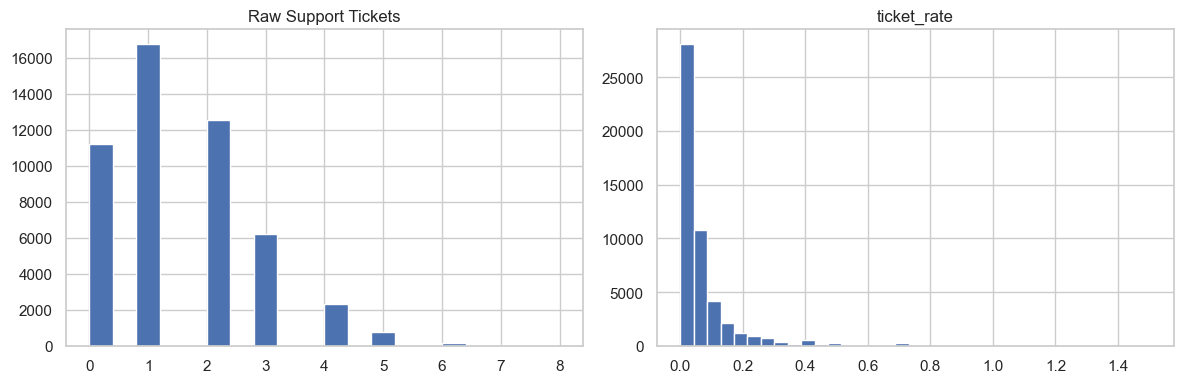

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df["num_support_tickets"],
    bins=20,
)

axes[0].set_title(
    "Raw Support Tickets"
)

axes[1].hist(
    df["ticket_rate"],
    bins=35,
)

axes[1].set_title(
    "ticket_rate"
)

plt.tight_layout()
plt.show()


`ticket_rate` adjusts support activity relative to tenure. This helps distinguish between newer customers struggling early and older customers with occasional issues.

### 4.3 `spend_vs_plan`

This feature compares customer spend with the median spend for their plan.


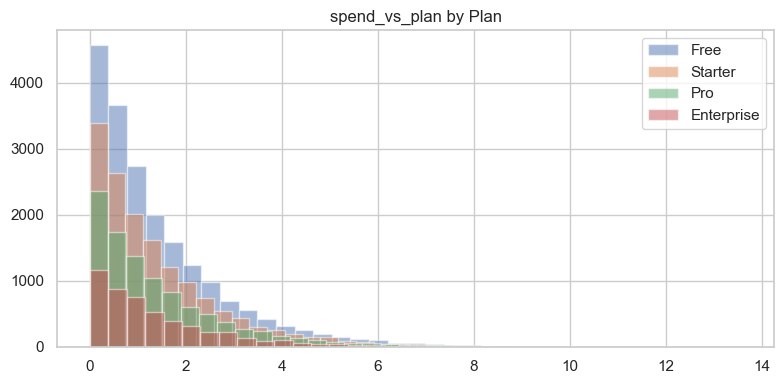

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for plan in [
    "Free",
    "Starter",
    "Pro",
    "Enterprise",
]:

    ax.hist(
        df.loc[df["plan_type"] == plan, "spend_vs_plan"],
        bins=35,
        alpha=0.5,
        label=plan,
    )

ax.set_title("spend_vs_plan by Plan")
ax.legend()

plt.tight_layout()
plt.show()


`spend_vs_plan` compares customer spend with the median spend for their plan tier.

### 4.4 `loyalty_score`

This feature combines:
- contract type
- tenure
- referrals

Longer-term customers generally appear more stable.


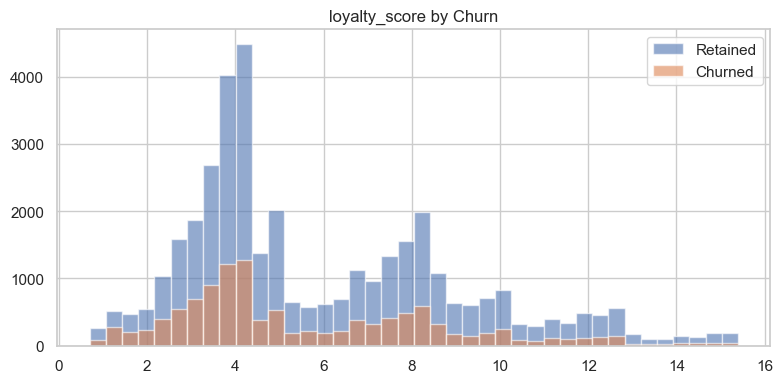

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, lbl in [
    (0, "Retained"),
    (1, "Churned"),
]:

    ax.hist(
        df.loc[df[TARGET] == label, "loyalty_score"],
        bins=40,
        alpha=0.6,
        label=lbl,
    )

ax.set_title(
    "loyalty_score by Churn"
)

ax.legend()

plt.tight_layout()
plt.show()


`loyalty_score` reflects customer stability using contract type, tenure, and referrals.

### 4.5 `risk_flag`

This feature groups customers into simple risk levels.


In [10]:
flag_summary = (
    df.groupby("risk_flag")[TARGET]
    .agg(["count", "mean"])
)

flag_summary


,count,mean
risk_flag,,
0,43177,0.210645
1,5449,0.391815
2,1374,0.472344


`risk_flag` groups customers into simple risk categories based on inactivity and engagement behaviour.

## 5. Distribution Analysis — All Engineered Features

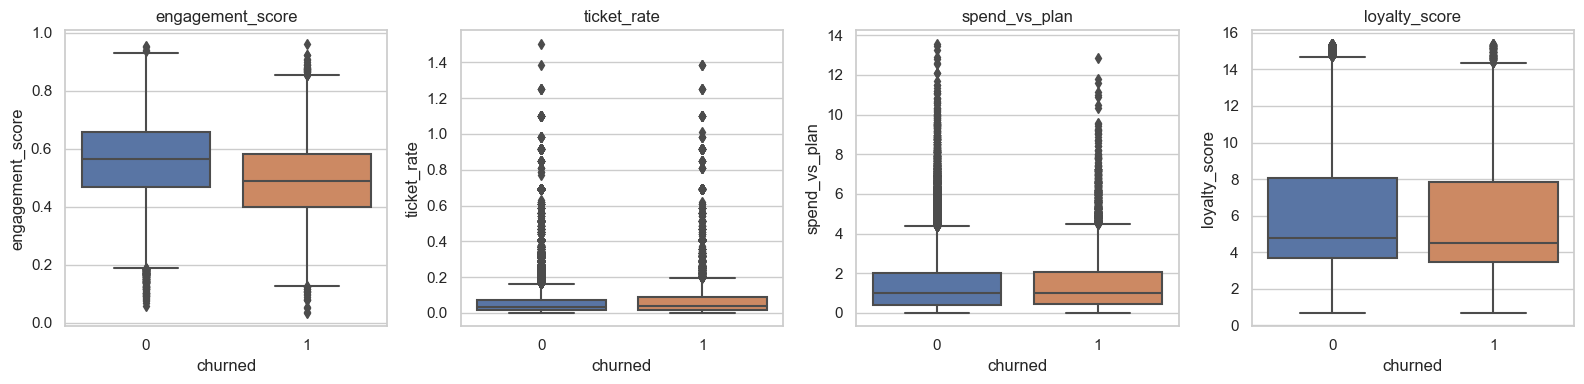

In [11]:
cont_features = [
    "engagement_score",
    "ticket_rate",
    "spend_vs_plan",
    "loyalty_score",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(
    axes,
    cont_features,
):

    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=ax,
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()


## 6. Correlation With Target

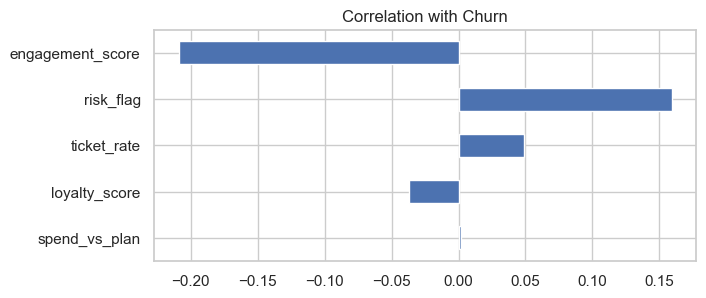

In [12]:
corr_with_target = (
    df[engineered + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs)
)

corr_with_target.plot(
    kind="barh",
    figsize=(7, 3),
)

plt.title(
    "Correlation with Churn"
)

plt.show()


The engineered features show moderate relationships with churn and may provide additional predictive value.

## 7. Key Observations

| Feature | What it captures | Why useful |
|---|---|---|
| `engagement_score` | Product usage | Lower engagement often relates to churn |
| `ticket_rate` | Support activity | Frequent issues may increase churn risk |
| `spend_vs_plan` | Spend relative to plan | Lower spenders may be less engaged |
| `loyalty_score` | Contract + tenure | Longer-term users are usually more stable |
| `risk_flag` | Simple risk grouping | Helps identify higher-risk customers |

The new features I created add extra behavioral signals, making it easier for the models to tell apart customers who are likely to churn from those who’ll stick around.